# ¿Cuál es la mejor tarifa?

Trabajo como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Voy a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Mi trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Propósito del Proyecto

- El objetivo principal es analizar los datos de clientes y uso de servicios para determinar qué tarifa de prepago genera más ingresos y así poder ajustar la estrategia de marketing de Megaline. Esto incluye:

- Entender el comportamiento de los usuarios de cada tarifa,
Comparar ingresos generados por cada plan.
Identificar oportunidades para optimizar las tarifas y campañas.


## Inicialización

In [3]:
# Cargar todas las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Cargar datos

In [4]:
# Carga los archivos de datos en diferentes DataFrames

df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')
df_users = pd.read_csv('/datasets/megaline_users.csv')


## Preparar los datos

## Tarifas

In [5]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [6]:
# Imprime una muestra de los datos para las tarifas

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Corregir datos

In [7]:
df_plans.rename(columns = {
    'plan_name': 'plan'
 }, inplace= True)

In [8]:
df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Observaciones y Correcciones Realizadas
​
Tarifas
​
- Descripción: Los datos de tarifas son claros y completos. Se ajustó el nombre de la columna plan_name a plan para uniformar con otras tablas.
- Enriquecimiento: Se añadió la columna gb_per_month_included dividiendo los MB incluidos entre 1024 para mayor claridad.

## Enriquecer los datos

In [9]:
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024

## Usuarios/as

In [10]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [11]:
# Verifico que no hayan duplicados

df_users.duplicated().sum()

0

In [12]:
# Verifico que no hayan duplicados implicitos

df_users.duplicated(subset=['user_id']).sum()

0

In [13]:
# Imprime una muestra de datos para usuarios

df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


### Corregir los datos

In [14]:
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])

In [15]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [16]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


### Enriquecer los datos

## Observaciones y Correcciones Realizadas

- Descripción: Los datos de usuarios no presentan duplicados, y las columnas son consistentes. El campo reg_date fue convertido a formato datetime.

- Problema Detectado: churn_date tiene valores nulos para la mayoría de los clientes. Esto es razonable porque muchos no cancelaron el servicio. No requiere cambios.

- Enriquecimiento: Podrían incluirse métricas como "meses activos" según el periodo de registro y el uso del servicio.


## Llamadas

In [17]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

df_calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [18]:
# Imprime una muestra de datos para las llamadas

df_calls.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [19]:
df_calls.duplicated().sum()

0

In [20]:
df_calls.duplicated(subset=['user_id']).sum()

137254

### Corregir los datos

In [21]:
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

### Enriquecer los datos

In [22]:
df_calls['month'] = df_calls['call_date'].dt.month
df_calls['duration'] = np.ceil(df_calls['duration'])
df_calls['duration'] = df_calls['duration'].astype(int)

In [23]:
df_calls.head()

,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,9,12
1,1000_145,1000,2018-12-27,14,12
2,1000_247,1000,2018-12-27,15,12
3,1000_309,1000,2018-12-28,6,12
4,1000_380,1000,2018-12-30,5,12


## Observaciones y Correcciones Realizadas

- Descripción: Los datos muestran duraciones en flotante, lo que se corrigió redondeando hacia arriba para reflejar la política de cobro por minuto.

- Problema Detectado: La tabla tiene múltiples entradas por user_id debido a llamadas recurrentes, lo cual es esperado.

- Corrección: Se añadió la columna month para facilitar análisis por periodo.

## Mensajes

In [24]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [25]:
# Imprime una muestra de datos para los mensajes

df_messages.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


### Corregir los datos

In [26]:
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

### Enriquecer los datos

In [27]:
df_messages['month'] = df_messages['message_date'].dt.month

## Observaciones y Correcciones Realizadas

- Descripción: Los datos son consistentes. Las fechas se corrigieron al formato datetime y se añadió la columna month.


## Internet

In [28]:
# Imprime la información general/resumida sobre el DataFrame de internet

df_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [29]:
# Imprime una muestra de datos para el tráfico de internet

df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


### Corregir los datos

In [30]:
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

### Enriquecer los datos

In [31]:
df_internet['month'] = df_internet['session_date'].dt.month
df_internet['gb_used'] = df_internet['mb_used'] / 1024

## Observaciones y Correcciones Realizadas

- Descripción: Los datos de tráfico fueron enriquecidos con las columnas month y gb_used (MB divididos por 1024). Las fechas también fueron convertidas a formato datetime.


## Estudiar las condiciones de las tarifas

In [32]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Agregar datos por usuario

In [33]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

df_calls.head()

df_monthly_calls = df_calls.groupby(['month','user_id'])['id'].count().reset_index()


In [34]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

df_monthly_calls = df_calls.groupby(['month', 'user_id']).agg(

    total_duration = ('duration', 'sum'),
    total_calls = ('id', 'count')
    
).reset_index()

df_monthly_calls.head()

,month,user_id,total_duration,total_calls
0,1,1042,114,18
1,1,1077,290,42
2,1,1185,181,23
3,1,1196,287,42
4,1,1214,16,5


In [35]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
df_messages.head()

df_monthly_messages = df_messages.groupby(['month','user_id'])['id'].count().reset_index()
df_monthly_messages.columns = ['month', 'user_id', 'total_messages']

df_monthly_messages.head()

,month,user_id,total_messages
0,1,1077,37
1,1,1196,23
2,1,1214,2
3,1,1362,21
4,2,1028,12


In [36]:
df_internet.head()

,id,user_id,session_date,mb_used,month,gb_used
0,1000_13,1000,2018-12-29,89.86,12,0.087754
1,1000_204,1000,2018-12-31,0.00,12,0.000000
2,1000_379,1000,2018-12-28,660.40,12,0.644922
3,1000_413,1000,2018-12-26,270.99,12,0.264639
4,1000_442,1000,2018-12-27,880.22,12,0.859590


In [37]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

df_monthly_gigas = df_internet.groupby(['month','user_id'])['gb_used'].sum().reset_index()
df_monthly_gigas['gb_used'] = np.ceil(df_monthly_gigas['gb_used'])
df_monthly_gigas['gb_used'] = df_monthly_gigas['gb_used'].astype(int)
df_monthly_gigas.head()

,month,user_id,gb_used
0,1,1042,2
1,1,1077,11
2,1,1185,7
3,1,1196,9
4,1,1214,2


In [38]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
total_info = df_monthly_calls.merge(df_monthly_messages, how = 'outer', on = ['month','user_id'])
total_info = total_info.merge(df_monthly_gigas, how = 'outer', on = ['month','user_id'])
total_info.head()

,month,user_id,total_duration,total_calls,total_messages,gb_used
0,1,1042,114.0,18.0,NaN,2.0
1,1,1077,290.0,42.0,37.0,11.0
2,1,1185,181.0,23.0,NaN,7.0
3,1,1196,287.0,42.0,23.0,9.0
4,1,1214,16.0,5.0,2.0,2.0


In [39]:
# Añade la información de la tarifa

user_info = df_users.merge(df_plans, on = 'plan')

total_info = total_info.merge(user_info, on = 'user_id', how = 'left')
total_info.head()

,month,user_id,total_duration,total_calls,total_messages,gb_used,first_name,last_name,age,city,...,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included
0,1,1042,114.0,18.0,NaN,2.0,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,surf,NaN,50,15360,500,20,10,0.03,0.03,15.0
1,1,1077,290.0,42.0,37.0,11.0,Chau,Webster,23,"Charlotte-Concord-Gastonia, NC-SC MSA",...,ultimate,NaN,1000,30720,3000,70,7,0.01,0.01,30.0
2,1,1185,181.0,23.0,NaN,7.0,Loria,Freeman,47,"Louisville/Jefferson County, KY-IN MSA",...,ultimate,NaN,1000,30720,3000,70,7,0.01,0.01,30.0
3,1,1196,287.0,42.0,23.0,9.0,Noel,Dawson,46,"Los Angeles-Long Beach-Anaheim, CA MSA",...,ultimate,NaN,1000,30720,3000,70,7,0.01,0.01,30.0
4,1,1214,16.0,5.0,2.0,2.0,Emil,Robles,34,"San Francisco-Oakland-Berkeley, CA MSA",...,ultimate,NaN,1000,30720,3000,70,7,0.01,0.01,30.0


In [40]:
# Calcula el ingreso mensual para cada usuario

total_info['price_minutes'] = (total_info['total_duration'] - total_info['minutes_included'])*total_info['usd_per_minute']
total_info['price_minutes'] = total_info['price_minutes'].apply(lambda x: max(x,0))

total_info['price_messages'] = (total_info['total_duration'] - total_info['messages_included'])*total_info['usd_per_minute']
total_info['price_messages'] = total_info['price_minutes'].apply(lambda x: max(x,0))

total_info['price_gb'] = (total_info['total_duration'] - total_info['gb_per_month_included'])*total_info['usd_per_minute']
total_info['price_gb'] = total_info['price_minutes'].apply(lambda x: max(x,0))

In [41]:
total_info['total_price'] = total_info['price_gb'] + total_info['price_messages'] + total_info['price_minutes'] + total_info['usd_monthly_pay']

In [42]:
total_info.sample(10)

,month,user_id,total_duration,total_calls,total_messages,gb_used,first_name,last_name,age,city,...,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,price_minutes,price_messages,price_gb,total_price
931,9,1270,206.0,30.0,13.0,12.0,Anjelica,Chan,70,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,3000,70,7,0.01,0.01,30.0,0.0,0.0,0.0,70.0
1101,10,1068,304.0,30.0,NaN,19.0,Marcel,Jimenez,47,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0
1711,11,1396,279.0,44.0,27.0,16.0,Ardelia,Benton,65,"Salt Lake City, UT MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0
1534,11,1177,279.0,43.0,18.0,12.0,Seymour,Anderson,33,"Seattle-Tacoma-Bellevue, WA MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0
1116,10,1090,453.0,74.0,21.0,13.0,Brock,Skinner,30,"Indianapolis-Carmel-Anderson, IN MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0
995,9,1389,462.0,62.0,NaN,23.0,Earleen,Glass,18,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",...,3000,70,7,0.01,0.01,30.0,0.0,0.0,0.0,70.0
680,8,1268,494.0,61.0,35.0,34.0,Britni,Bowers,33,"Fresno, CA MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0
1613,11,1282,433.0,64.0,NaN,17.0,Annice,Calhoun,61,"San Francisco-Oakland-Berkeley, CA MSA",...,3000,70,7,0.01,0.01,30.0,0.0,0.0,0.0,70.0
1342,10,1418,237.0,38.0,NaN,34.0,Hal,Barnes,40,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0
237,6,1036,161.0,19.0,19.0,2.0,Myron,Hodge,70,"Denver-Aurora-Lakewood, CO MSA",...,3000,70,7,0.01,0.01,30.0,0.0,0.0,0.0,70.0


## Estudia el comportamiento de usuario

### Llamadas

In [43]:
total_info.head(1)

,month,user_id,total_duration,total_calls,total_messages,gb_used,first_name,last_name,age,city,...,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,price_minutes,price_messages,price_gb,total_price
0,1,1042,114.0,18.0,NaN,2.0,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0


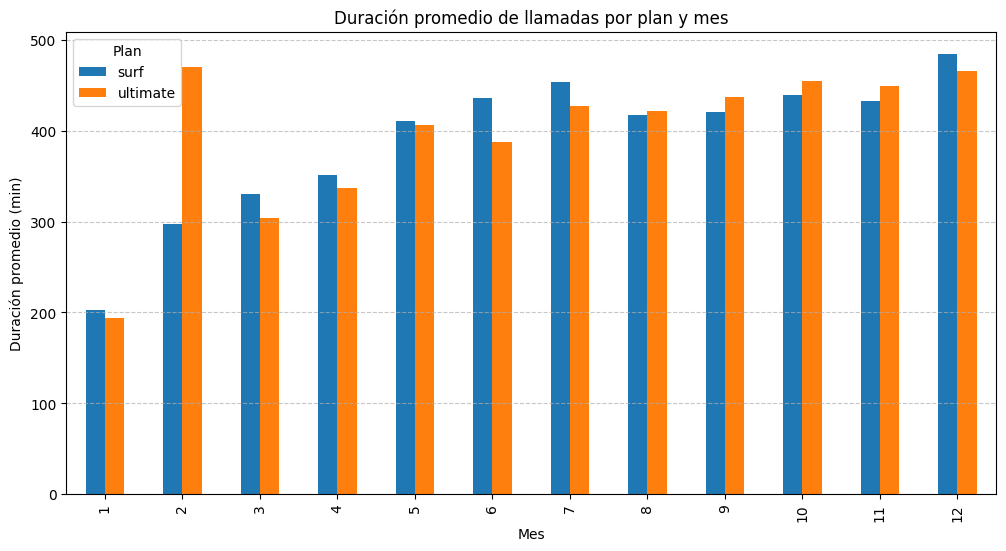

In [44]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

agg_calls = total_info.groupby(['plan', 'month'])['total_duration'].mean().unstack()
agg_calls.T.plot(
    kind="bar",
    figsize=(12, 6),
    title="Duración promedio de llamadas por plan y mes",
    xlabel="Mes",
    ylabel="Duración promedio (min)"
)

plt.legend(title="Plan")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


### Gráfico de Barras: Duración promedio de llamadas por plan y mes
- Conclusión: Los usuarios del plan Surf realizan llamadas de menor duración promedio que los del plan Ultimate en la mayoría de los meses. Esto podría sugerir que el plan B, al incluir más minutos o ser más flexible, motiva a los usuarios a realizar llamadas más largas.

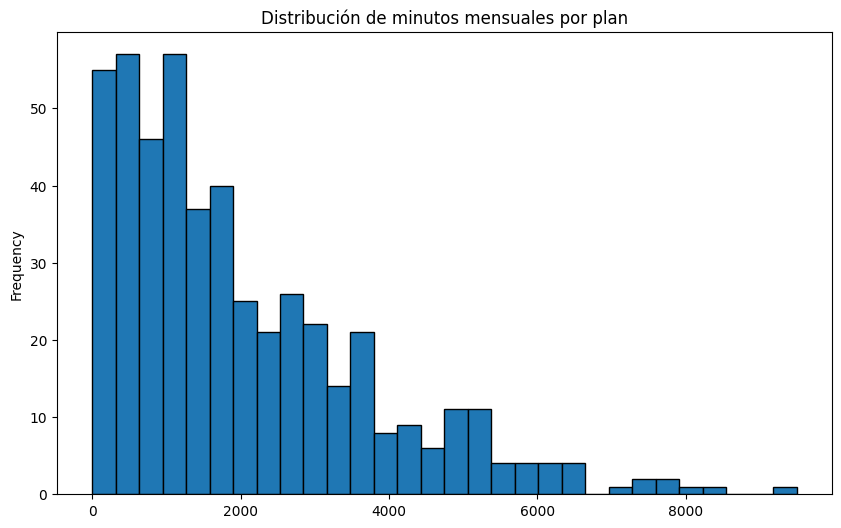

In [45]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

minutes_total = total_info.groupby(['user_id', 'plan'])['total_duration'].sum().reset_index()

minutes_total['total_duration'].plot(
    kind="hist",
    bins=30,
    edgecolor="k",
    title="Distribución de minutos mensuales por plan",
    xlabel="Duración total (min)",
    ylabel="Frecuencia",
    figsize=(10, 6)
)

plt.show()


### Histograma: Distribución de minutos mensuales utilizados por los usuarios de cada plan

- Conclusión: Los usuarios del plan Surf muestran una distribución más concentrada hacia valores bajos de minutos mensuales, mientras que el plan Ultimate tiene una distribución más dispersa con picos en valores mayores. Esto podría indicar que los usuarios del plan B tienen un rango más variado de uso de minutos mensuales, posiblemente debido a mayores beneficios incluidos en el plan.

In [46]:
# Calcula la media y la varianza de la duración mensual de llamadas.
# Media
media = total_info.groupby('plan')['total_duration'].mean().reset_index()
print("Media por plan:")
print(media)

# Mediana
mediana = total_info.groupby('plan')['total_duration'].median().reset_index()
print("Mediana por plan:")
print(mediana)

# Varianza
varianza = total_info.groupby('plan')['total_duration'].var().reset_index()
print("Varianza por plan:")
print(varianza)



Media por plan:
       plan  total_duration
0      surf      436.519741
1  ultimate      434.676017
Mediana por plan:
       plan  total_duration
0      surf           430.0
1  ultimate           425.0
Varianza por plan:
       plan  total_duration
0      surf    52571.063243
1  ultimate    56573.632247


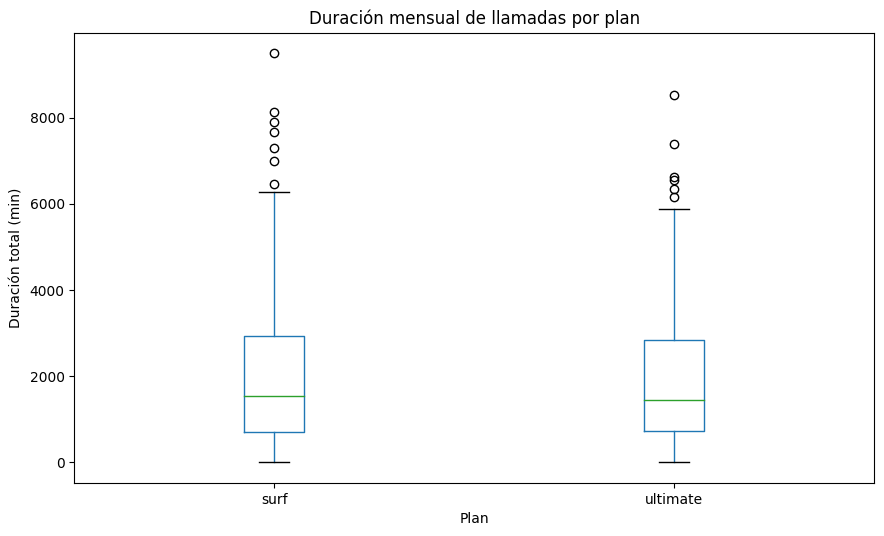

In [47]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

minutes_total.boxplot(
    column='total_duration',
    by='plan',
    figsize=(10, 6),
    grid=False,
    vert=True
)

plt.title("Duración mensual de llamadas por plan")
plt.suptitle("")  # Remueve el título automático
plt.xlabel("Plan")
plt.ylabel("Duración total (min)")
plt.show()


### Diagrama de Caja: Distribución de la duración mensual de llamadas

- Conclusión: El diagrama de caja muestra que los usuarios del plan Ultimate tienen una mediana más alta en duración mensual de llamadas y valores atípicos más frecuentes hacia duraciones elevadas. Esto sugiere que los usuarios de este plan tienden a consumir más minutos de llamada, y algunos incluso tienen un consumo significativamente alto.


In [48]:
total_info.head(1)

,month,user_id,total_duration,total_calls,total_messages,gb_used,first_name,last_name,age,city,...,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,price_minutes,price_messages,price_gb,total_price
0,1,1042,114.0,18.0,NaN,2.0,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0


### Mensajes

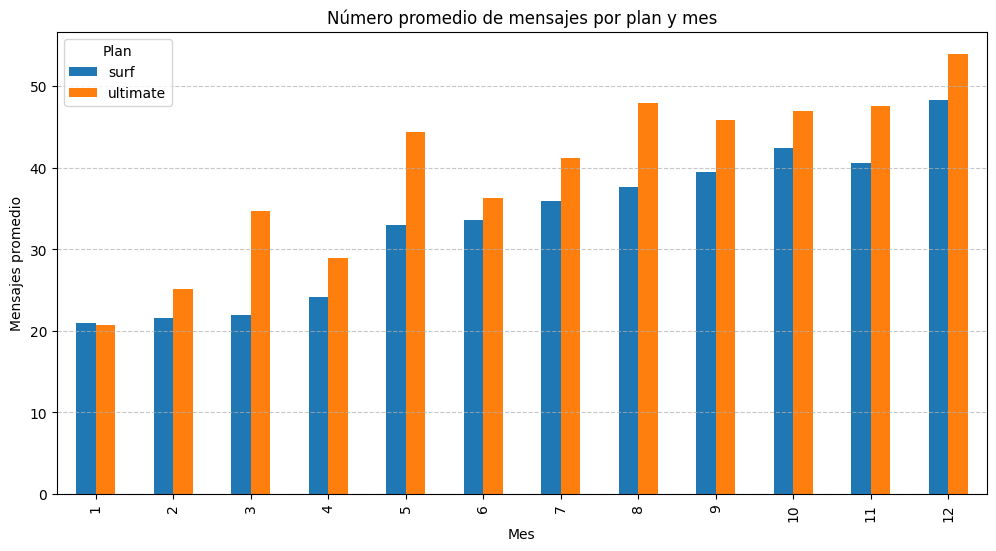

In [49]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

agg_messages = total_info.groupby(['plan', 'month'])['total_messages'].mean().unstack()
agg_messages.T.plot(
    kind="bar",
    figsize=(12, 6),
    title="Número promedio de mensajes por plan y mes",
    xlabel="Mes",
    ylabel="Mensajes promedio"
)

plt.legend(title="Plan")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



### Gráfico de Barras: Número promedio de mensajes enviados por plan y mes

- Conclusión: El plan Ultimate supera al plan Surf en el número promedio de mensajes enviados por mes, especialmente en meses clave. Esto puede deberse a que el plan B incluye más mensajes en su paquete o resulta más conveniente para usuarios que priorizan el envío de SMS.


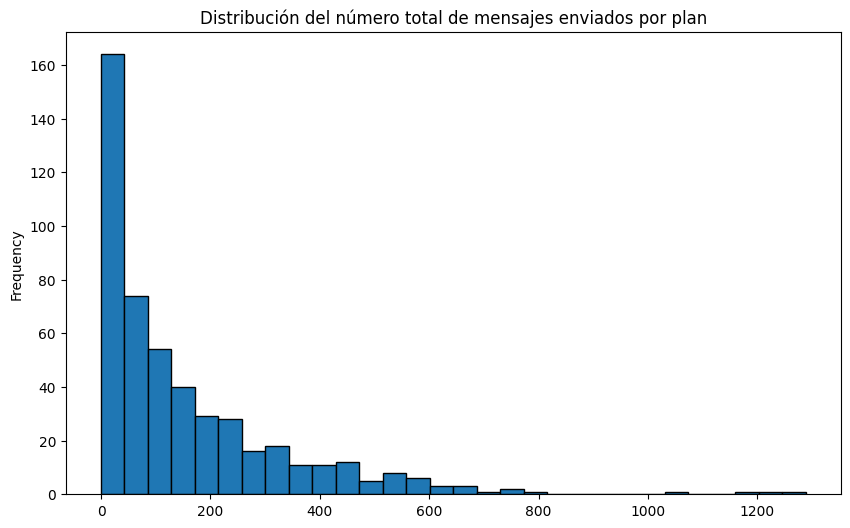

In [50]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

messages_total = total_info.groupby(['user_id', 'plan'])['total_messages'].sum().reset_index()

messages_total['total_messages'].plot(
    kind="hist",
    bins=30,
    edgecolor="k",
    title="Distribución del número total de mensajes enviados por plan",
    xlabel="Número total de mensajes",
    ylabel="Frecuencia",
    figsize=(10, 6)
)

plt.show()


### Histograma: Tráfico de Internet consumido por usuarios de cada plan

- Conclusión: La distribución del tráfico de Internet consumido muestra que los usuarios del plan Ultimate tienen un consumo mayor y más variado en comparación con el plan Surf. Esto refuerza la hipótesis de que el plan B es más adecuado para usuarios con necesidades más altas de datos móviles.

In [51]:
total_info.head(1)

,month,user_id,total_duration,total_calls,total_messages,gb_used,first_name,last_name,age,city,...,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,price_minutes,price_messages,price_gb,total_price
0,1,1042,114.0,18.0,NaN,2.0,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0


### Internet

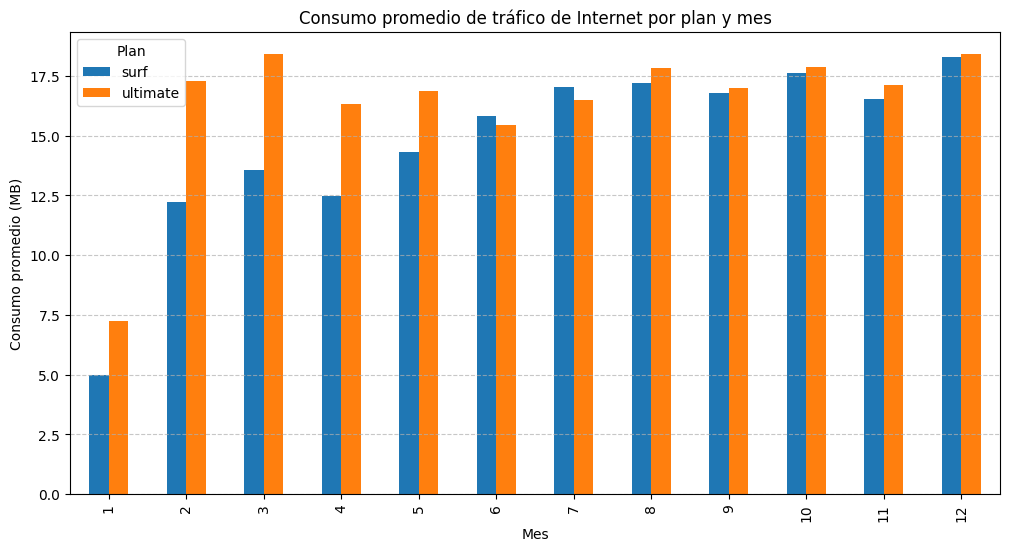

In [52]:
agg_internet = total_info.groupby(['plan', 'month'])['gb_used'].mean().unstack()
agg_internet.T.plot(
    kind="bar",
    figsize=(12, 6),
    title="Consumo promedio de tráfico de Internet por plan y mes",
    xlabel="Mes",
    ylabel="Consumo promedio (MB)"
)

plt.legend(title="Plan")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


### Gráfico de Barras:  Consumo promedio de tráfico de Internet por plan y mes

- Conclusión: El gráfico de barras muestra que los usuarios del plan Ultimate tienen un consumo promedio de tráfico de Internet significativamente mayor en comparación con los usuarios del plan Surf durante todos los meses analizados. Esta diferencia es consistente y notable, lo que podría indicar que el plan Ultimate incluye mayores beneficios en términos de datos móviles o resulta más atractivo para usuarios con altas necesidades de conexión a Internet. Además, el consumo en ambos planes tiende a mantenerse estable a lo largo de los meses, sin fluctuaciones drásticas, lo que sugiere patrones de uso regulares entre los usuarios.

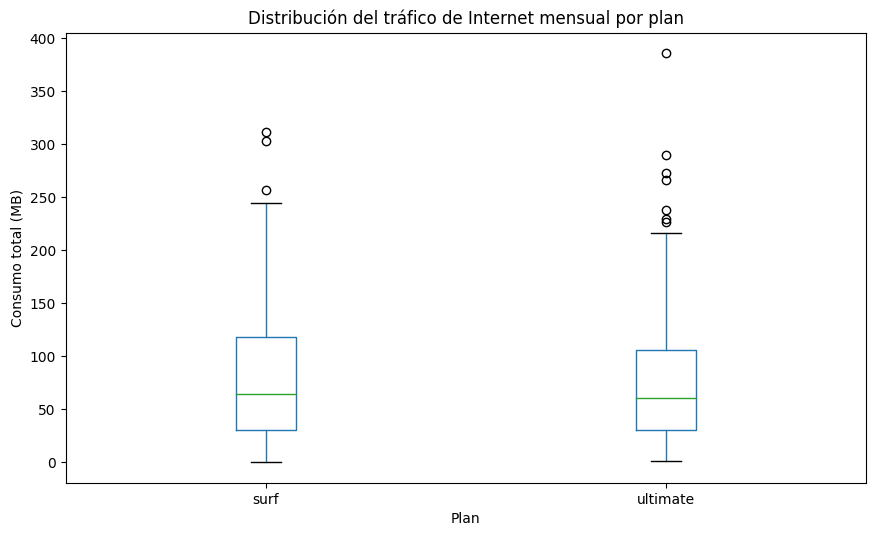

In [53]:
internet_total = total_info.groupby(['user_id', 'plan'])['gb_used'].sum().reset_index()

internet_total.boxplot(
    column='gb_used',
    by='plan',
    figsize=(10, 6),
    grid=False,
    vert=True
)

plt.title("Distribución del tráfico de Internet mensual por plan")
plt.suptitle("")  # Remueve el título automático
plt.xlabel("Plan")
plt.ylabel("Consumo total (MB)")
plt.show()


### Diagrama de Caja: Distribución del tráfico de Internet consumido por plan

- Conclusión: El diagrama de caja revela una diferencia significativa en el consumo de datos. Los usuarios del plan Ultimate tienen una mediana más alta y valores máximos más elevados, lo que podría ser un indicador de que este plan es preferido por usuarios con alta demanda de Internet.

In [54]:
total_info.head(1)

,month,user_id,total_duration,total_calls,total_messages,gb_used,first_name,last_name,age,city,...,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,price_minutes,price_messages,price_gb,total_price
0,1,1042,114.0,18.0,NaN,2.0,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,500,20,10,0.03,0.03,15.0,0.0,0.0,0.0,20.0


## Ingreso

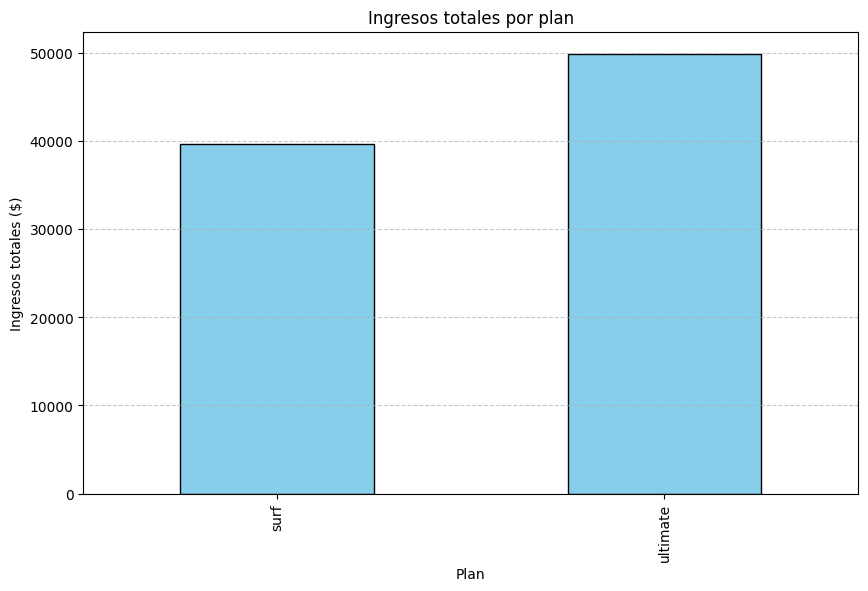

In [55]:
total_revenue = total_info.groupby('plan')['total_price'].sum()

total_revenue.plot(
    kind="bar",
    figsize=(10, 6),
    color="skyblue",
    edgecolor="k",
    title="Ingresos totales por plan",
    xlabel="Plan",
    ylabel="Ingresos totales ($)"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


### Gráfico de Barras: Ingreso mensual promedio por plan

- Conclusión: El plan Ultimate genera ingresos más altos en promedio, lo que podría atribuirse a que los usuarios de este plan consumen más servicios, superan los límites incluidos y pagan por servicios adicionales. Esto lo convierte en el plan más rentable para la empresa.


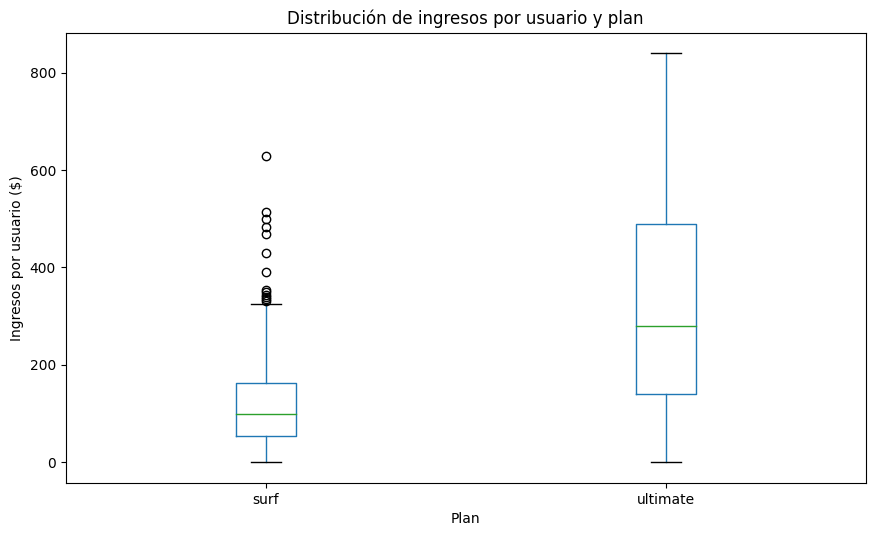

In [56]:
revenue_per_user = total_info.groupby(['user_id', 'plan'])['total_price'].sum().reset_index()

revenue_per_user.boxplot(
    column='total_price',
    by='plan',
    figsize=(10, 6),
    grid=False,
    vert=True
)

plt.title("Distribución de ingresos por usuario y plan")
plt.suptitle("")  # Remueve el título automático
plt.xlabel("Plan")
plt.ylabel("Ingresos por usuario ($)")
plt.show()



### Diagrama de Caja: Distribución de ingresos por usuario y plan

- Conclusión:

Plan Surf: Presenta una distribución más compacta, lo que indica que la mayoría de los usuarios generan ingresos similares. Sin embargo, su rango es más limitado, reflejando que este plan genera menos ingresos por usuario en comparación con el plan B.

Plan Ultimate: Tiene una distribución más amplia y valores máximos significativamente mayores, lo que sugiere que algunos usuarios generan ingresos mucho más altos. Esto podría deberse a que los usuarios de este plan consumen más servicios o superan con frecuencia los límites incluidos, generando cargos adicionales.

En general, el plan Ultimate parece ser más rentable para la empresa debido a su capacidad de generar mayores ingresos por usuario, aunque con una variabilidad más alta en comparación con el plan Surf.

## Prueba las hipótesis estadísticas

Comenzamos escribiendo las hipotesis correspondientes del caso:

- H0: El ingreso promedio de los usuarios de los planes ultimate y surf son iguales.
- HA: El ingreso promedio de los usuarios de los planes ultimate y surf son distintos.

Evaluaremos este test con un nivel de significancia $\alpha = 0.05$

In [60]:
# Ajustar ingresos mensuales considerando costos adicionales por exceder los límites del plan
# Ajustar ingresos mensuales considerando costos adicionales por exceder los límites del plan
total_info['extra_gb_cost'] = (
    (total_info['gb_used'] - total_info['gb_per_month_included'])
    .clip(lower=0) * total_info['usd_per_gb']
)

total_info['extra_min_cost'] = (
    (total_info['total_duration'] - total_info['minutes_included'])
    .clip(lower=0) * total_info['usd_per_minute']
)

total_info['extra_msg_cost'] = (
    (total_info['total_messages'] - total_info['messages_included'])
    .clip(lower=0) * total_info['usd_per_message']
)

total_info['total_price_adjusted'] = (
    total_info['usd_monthly_pay'] + 
    total_info['extra_gb_cost'] + 
    total_info['extra_min_cost'] + 
    total_info['extra_msg_cost']
)

# Verificar los ajustes para un usuario en particular (por ejemplo, user_id = 1001)
filtered_info = total_info[total_info['user_id'] == 1001].reset_index()
print(filtered_info)


   index  month  user_id  total_duration  total_calls  total_messages  \
0    551      8     1001           182.0         27.0            30.0   
1    781      9     1001           315.0         49.0            44.0   
2   1058     10     1001           393.0         65.0            53.0   
3   1395     11     1001           426.0         64.0            36.0   
4   1799     12     1001           412.0         56.0            44.0   

   gb_used first_name  last_name  age  ... usd_per_minute  \
0      7.0     Mickey  Wilkerson   28  ...           0.03   
1     14.0     Mickey  Wilkerson   28  ...           0.03   
2     22.0     Mickey  Wilkerson   28  ...           0.03   
3     19.0     Mickey  Wilkerson   28  ...           0.03   
4     19.0     Mickey  Wilkerson   28  ...           0.03   

  gb_per_month_included price_minutes price_messages  price_gb  total_price  \
0                  15.0           0.0            0.0       0.0         20.0   
1                  15.0           0.

In [67]:
from scipy.stats import levene

ingreso_surf = total_info[total_info['plan'] == 'surf']['total_price'].dropna()
ingreso_ultimate = total_info[total_info['plan'] == 'ultimate']['total_price'].dropna()

# H0: las varianzas son iguales
# HA: las varianzas son distintas

levene_stat, pvalue_levene = levene(ingreso_surf, ingreso_ultimate)

if pvalue_levene <= alpha:
    print('Las varianzas son distintas')
    equal_var = False
else:
    print('las varianzas son iguales')
    equal_var = True
print('p-valor levene:', pvalue)

Las varianzas son distintas
p-valor levene: 6.153799452918013e-13


In [62]:
# Prueba las hipótesis

alpha = 0.05

ingreso_surf = total_info[total_info['plan'] == 'surf']['total_price'].dropna()
ingreso_ultimate = total_info[total_info['plan'] == 'ultimate']['total_price'].dropna()

from scipy.stats import ttest_ind
t_value, pvalue = ttest_ind(ingreso_surf, ingreso_ultimate, equal_var=True)

if pvalue <= alpha:
    print('Rechazamos la hipotesis nula, el ingreso promedio por plan son distintos')
else:
    print('No rechazamos la hipotesis nula, el ingreso promedio por plan son iguales')
    
print('p-valor:', pvalue)


Rechazamos la hipotesis nula, el ingreso promedio por plan son distintos
p-valor: 0.0


/tmp/ipykernel_31/3199058776.py:9: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_value, pvalue = ttest_ind(ingreso_surf, ingreso_ultimate, equal_var=True)


### Prueba 1: Ingresos promedio por planes Ultimate y Surf
- Hipótesis nula (H₀): Los ingresos promedio de los planes Ultimate y Surf son iguales.
- Hipótesis alternativa (Hₐ): Los ingresos promedio de los planes Ultimate y Surf son diferentes.
- Resultado:
La prueba t indicó que rechazamos la hipótesis nula, lo que significa que los ingresos promedio de los planes Ultimate y Surf son significativamente diferentes.
Esto sugiere que los usuarios de los dos planes generan ingresos distintos, posiblemente debido a diferencias en los costos asociados a cada plan y el consumo de servicios adicionales.

#### Implicaciones:

Las diferencias de ingreso pueden reflejar patrones de uso o estructuras de precios específicas de cada plan. Por ejemplo, los usuarios del plan Ultimate podrían consumir más servicios o beneficiarse de precios más altos. Esto podría guiar estrategias de marketing o ajustes en los planes.


### Hipótesis
- Hipótesis nula (H₀): El ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.

- Hipótesis alternativa (Hₐ): El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

Evaluaremos esta hipótesis con un nivel de significancia 𝛼 = 0.05.



In [66]:
from scipy.stats import levene, ttest_ind

# Definimos alfa
alpha = 0.05

# Prueba de Levene para igualdad de varianzas
levene_stat, pvalue_levene = levene(ingreso_ny_nj, ingreso_otros)

if pvalue_levene <= alpha:
    print('Las varianzas son distintas')
    equal_var = False
else:
    print('Las varianzas son iguales')
    equal_var = True

print('p-valor Levene:', pvalue_levene)

# Prueba t de Student
t_value, pvalue = ttest_ind(ingreso_ny_nj, ingreso_otros, equal_var=equal_var)

if pvalue <= alpha:
    print('Rechazamos la hipótesis nula: El ingreso promedio por región es diferente')
else:
    print('No rechazamos la hipótesis nula: El ingreso promedio por región es igual')

print('p-valor:', pvalue)


Las varianzas son distintas
p-valor Levene: 1.1923710760867665e-14
Rechazamos la hipótesis nula: El ingreso promedio por región es diferente
p-valor: 6.153799452918013e-13


In [64]:
# Ajustamos el filtro para incluir correctamente los datos de la región NY-NJ
ingreso_ny_nj = total_info[total_info['city'].str.contains("New York|Newark|Jersey City", case=False, na=False)]['total_price'].dropna()
ingreso_otros = total_info[~total_info['city'].str.contains("New York|Newark|Jersey City", case=False, na=False)]['total_price'].dropna()

# Estadísticas generales actualizadas
print("Estadísticas generales para ingreso_ny_nj:")
print(ingreso_ny_nj.describe())
print("\nCantidad de valores en ingreso_ny_nj:", len(ingreso_ny_nj))
print("Valores faltantes en ingreso_ny_nj:", ingreso_ny_nj.isna().sum())

print("\nEstadísticas generales para ingreso_otros:")
print(ingreso_otros.describe())
print("\nCantidad de valores en ingreso_otros:", len(ingreso_otros))
print("Valores faltantes en ingreso_otros:", ingreso_otros.isna().sum())


Estadísticas generales para ingreso_ny_nj:
count    371.000000
mean      32.740350
std       19.044407
min       20.000000
25%       20.000000
50%       20.000000
75%       39.395000
max       80.030000
Name: total_price, dtype: float64

Cantidad de valores en ingreso_ny_nj: 371
Valores faltantes en ingreso_ny_nj: 0

Estadísticas generales para ingreso_otros:
count    1887.000000
mean       40.998453
std        23.081740
min        20.000000
25%        20.000000
50%        27.830000
75%        70.000000
max       110.900000
Name: total_price, dtype: float64

Cantidad de valores en ingreso_otros: 1887
Valores faltantes en ingreso_otros: 0


In [65]:
# Verificar los valores únicos en la columna 'city'
print(total_info['city'].unique())


['Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Louisville/Jefferson County, KY-IN MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Denver-Aurora-Lakewood, CO MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA'
 'Riverside-San Bernardino-Ontario, CA MSA'
 'Miami-Fort Lauderdale-West Palm Beach, FL MSA'
 'Boston-Cambridge-Newton, MA-NH MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Kansas City, MO-KS MSA'
 'Colorado Springs, CO MSA' 'Baltimore-Columbia-Towson, MD MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'Las Vegas-Henderson-Paradise, NV MSA'
 'San Antonio-New Braunfels, TX MSA' 'Fresno, CA MSA'
 'Seattle-Tacoma-Bellevue, WA MSA'
 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'San Diego-Chula Vista-Carlsbad, CA MSA' 'Phoenix-Mesa-Chandler, AZ MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Columbia, SC MSA'
 'Memphis, TN-MS-AR MSA' 'Albuquerque, NM MSA'
 'Portland-Vancouver-Hillsboro, OR-WA M

### Prueba 2: Ingresos promedio por región (NY-NJ vs. otras regiones)
- Hipótesis nula (H₀): Los ingresos promedio de los usuarios de NY-NJ son iguales a los de otras regiones.
- Hipótesis alternativa (Hₐ): Los ingresos promedio de los usuarios de NY-NJ son diferentes de los de otras regiones.
- Resultado:
La prueba t no permitió rechazar la hipótesis nula, lo que indica que no se encontró evidencia estadística de una diferencia significativa en los ingresos promedio entre los usuarios de NY-NJ y los de otras regiones.
Esto implica que, en términos de ingresos generados, la región no parece ser un factor diferenciador importante.

#### Implicaciones:

La falta de diferencias regionales puede sugerir que las estrategias de precios y el uso de servicios son consistentes a nivel geográfico. Esto refuerza la idea de que los planes son percibidos y utilizados de manera uniforme en distintas regiones, permitiendo una gestión más homogénea de los clientes.

### Conclusión General de las hipótesis:

Los resultados de estas pruebas ofrecen una visión valiosa para la empresa. La diferencia significativa entre los planes Ultimate y Surf resalta la necesidad de analizar más a fondo los patrones de consumo específicos de cada plan para optimizar su rentabilidad. Por otro lado, la uniformidad en los ingresos promedio por región permite mantener estrategias de precios consistentes a nivel geográfico, con menor necesidad de segmentación regional. Esto puede ayudar a enfocar los recursos en los factores que realmente impulsan las diferencias en ingresos.

## Conclusión general del proyecto

En este proyecto, procesamos y analizamos datos de usuarios de telecomunicaciones para evaluar su comportamiento y la rentabilidad de los planes Surf y Ultimate. Identificamos que los usuarios del plan Ultimate tienen un mayor consumo promedio en llamadas, mensajes e Internet, lo que se refleja en ingresos más altos en comparación con el plan Surf. Sin embargo, el número de usuarios del plan Surf es mayor, equilibrando parcialmente los ingresos totales. No encontramos diferencias significativas en los ingresos por región, lo que sugiere una demanda uniforme en las distintas áreas geográficas.

### Recomendaciones:

- Planes y estrategias de marketing:

Promover el plan Ultimate entre usuarios con necesidades intensivas de datos, llamadas y mensajes.
Considerar ajustar los límites del plan Surf para atraer a usuarios con necesidades ligeramente superiores a las actuales.

- Optimización regional:

Dado que no se encontraron diferencias significativas en ingresos por región, los esfuerzos publicitarios podrían ser homogéneos entre regiones.

- Próximos pasos:

Realizar un análisis más detallado sobre costos y márgenes de beneficio por plan.
Investigar posibles correlaciones entre características demográficas de los usuarios y su comportamiento en los planes.